# Laboratorio 3 - Clasificación
### Sergio David Ferreira - Juan David Gutierrez

## Librerias utilizadas

In [31]:
import warnings

import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Carga y Exploración de Datos
Se cargan los datos y se realiza una copia de seguridad para mantener la integridad de la fuente. Se utiliza `.describe()` para entender la distribución de las variables numéricas (como edad, BMI y pasos diarios).

In [2]:
fitness_data = pd.read_csv('data/Datos_Laboratorio3.csv', sep=';')

data = fitness_data.copy()
data.describe()

,Edad,Peso,Altura,BMI,Horas_sueño,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


Definimos dos variables objetivo (Target): `Plan_entrenamiento` y `Plan_nutricion`.

In [3]:
X = data.drop(columns=['Plan_entrenamiento', 'Plan_nutricion'])

y_entrenamiento = data['Plan_entrenamiento']
y_nutricion = data['Plan_nutricion']

X_train, X_test, y_entrenamiento_train, y_entrenamiento_test, y_nutricion_train, y_nutricion_test = train_test_split(
    X, 
    y_entrenamiento, 
    y_nutricion, 
    test_size=0.2, 
    random_state=42
)

Se realiza un diagnóstico de valores faltantes. Como se observa en el análisis de `isnull()`, la variable `Peso` presenta datos faltantes, los cuales serán tratados mediante imputación dentro del pipeline para no perder filas valiosas de información.

In [4]:
( (X.isnull().sum() / X.shape[0]) ).sort_values(ascending=False)

Peso                       0.001134
Edad                       0.000000
Genero                     0.000000
Altura                     0.000000
BMI                        0.000000
Objetivo                   0.000000
Condicion_salud            0.000000
Nivel_Actividad            0.000000
Nivel_experiencia          0.000000
Dieta_preferida            0.000000
Horas_sueño                0.000000
Entrenamiento_preferido    0.000000
Cantidad_equipo            0.000000
Tiempo_disponible          0.000000
Tiene_alergia              0.000000
Problemas_digestivos       0.000000
Fumador                    0.000000
Cigarrillos_dia            0.000000
Alcohol                    0.000000
Alcohol_semana             0.000000
Score_micronutrientes      0.000000
Ingesta_proteinas          0.000000
Pasos_dia                  0.000000
Ingesta_agua               0.000000
dtype: float64

Ahora se aplica una estrategia diferenciada por tipo de variable:

1. **Variables Nominales:** Aplicamos `OneHotEncoder` para representar categorías sin orden intrínseco.
2. **Variables Ordinales:** Se utiliza `OrdinalEncoder` para preservar la jerarquía lógica en niveles de actividad y experiencia (Bajo < Moderado < Alto).
3. **Variables Numéricas:** Se preparan para ser escaladas (`StandardScaler`) para que variables con rangos grandes no dominen injustificadamente sobre variables de rango pequeño.

In [5]:
categorical_cols = X.select_dtypes(include=['str']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
ordinal_cols = ['Nivel_Actividad', 'Nivel_experiencia']
binary_cols = ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol']

categorical_cols = list(categorical_cols.drop(ordinal_cols))
numerical_cols = list(numerical_cols.drop(binary_cols))
encoder = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('ordinal', OrdinalEncoder(categories=[['Bajo', 'Moderado', 'Alto'], ['Principiante', 'Intermedio', 'Avanzado']]), ordinal_cols)
])

## Análisis de Distribución de Variables
Antes de modelar generamos histogramas para las variables numéricas con el fin de identificar:
* **Sesgos:** Si los datos están muy cargados a la izquierda o derecha.
* **Outliers:** Puntos que se alejan demasiado de la media y podrían confundir al modelo.
* **Escalas:** Confirmar que variables como "Pasos" y "Horas de sueño" necesitan normalización.

array([[<Axes: title={'center': 'Edad'}>,
        <Axes: title={'center': 'Peso'}>,
        <Axes: title={'center': 'Altura'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Horas_sueño'}>,
        <Axes: title={'center': 'Cantidad_equipo'}>,
        <Axes: title={'center': 'Tiempo_disponible'}>,
        <Axes: title={'center': 'Cigarrillos_dia'}>],
       [<Axes: title={'center': 'Alcohol_semana'}>,
        <Axes: title={'center': 'Score_micronutrientes'}>,
        <Axes: title={'center': 'Ingesta_proteinas'}>,
        <Axes: title={'center': 'Pasos_dia'}>],
       [<Axes: title={'center': 'Ingesta_agua'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

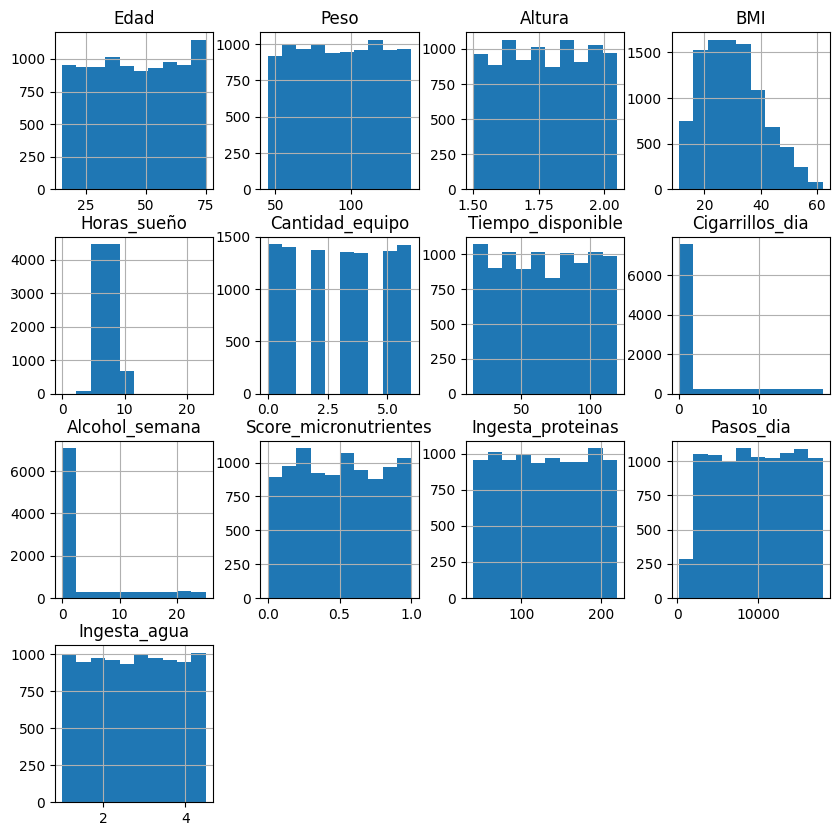

In [6]:
X[numerical_cols].hist(figsize=(10, 10))

En los datos detectamos valores en la variable `Horas_sueño` que podrían ser errores de entrada o casos extremos poco representativos. Utilizamos un `FunctionTransformer` para mantener los registros pero limitar sus valores a un rango biológicamente razonable.

In [7]:
def limiter(data):
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data, columns=numerical_cols + binary_cols)

    data = data.copy()
    data['Horas_sueño'] = data['Horas_sueño'].clip(4, 15)

    return data

limiter_transformer = FunctionTransformer(limiter)

Calculamos el **VIF**. Si es superior a 5 o 10 sugiere que una variable es redundante.

In [8]:
X_vif = add_constant(X[numerical_cols].dropna())

vif = pd.DataFrame()
vif['Variable'] = X_vif.columns
vif['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif[1:].sort_values('VIF', ascending=False))

                 Variable        VIF
4                     BMI  36.382162
2                    Peso  26.688595
3                  Altura  10.480731
10  Score_micronutrientes   1.002000
5             Horas_sueño   1.001908
7       Tiempo_disponible   1.001574
9          Alcohol_semana   1.001440
13           Ingesta_agua   1.001389
1                    Edad   1.001376
11      Ingesta_proteinas   1.001134
6         Cantidad_equipo   1.000672
8         Cigarrillos_dia   1.000604
12              Pasos_dia   1.000528


In [9]:
X_vif = add_constant(X[numerical_cols].dropna())
X_vif.drop(columns=['Peso'], inplace=True)

vif = pd.DataFrame()
vif['Variable'] = X_vif.columns
vif['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif[1:].sort_values('VIF', ascending=False))

                 Variable       VIF
2                  Altura  1.366228
3                     BMI  1.364274
4             Horas_sueño  1.001908
9   Score_micronutrientes  1.001690
8          Alcohol_semana  1.001280
1                    Edad  1.001178
6       Tiempo_disponible  1.001147
10      Ingesta_proteinas  1.001106
12           Ingesta_agua  1.001001
5         Cantidad_equipo  1.000672
7         Cigarrillos_dia  1.000568
11              Pasos_dia  1.000491


Decidimos eliminar `Peso` y otras variables redundantes (`Alcohol`, `Fumador`) para simplificar el modelo y reducir el ruido, manteniendo un VIF saludable en el resto de las columnas.

In [10]:
def dropper(data):
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data, columns=numerical_cols + binary_cols)

    return data.drop(columns=['Alcohol', 'Fumador', 'Peso'], errors='ignore')

dropper_transformer = FunctionTransformer(dropper)

#### Construcción del Pipeline
Finalmente, consolidamos todas las decisiones anteriores en un pipeline.

* **Imputación:** Usamos la **mediana** para rellenar valores faltantes, ya que es más robusta a los valores atípicos que el promedio.
* **Estandarización:** Aplicamos `StandardScaler` para que todas las variables tengan media 0 y desviación estándar 1.
* **Dropper:** Eliminamos las columnas identificadas en el análisis VIF para optimizar el rendimiento.
* **ColumnTransformer:** Esto nos permite aplicar el pipeline numérico a las columnas de medidas y el pipeline categórico a las de texto simultáneamente, dejando los datos listos para el entrenamiento.

In [11]:
numeric_transformer = Pipeline(steps=[
    ('limiter', limiter_transformer),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('dropper', dropper_transformer),
])

preprocessor = ColumnTransformer(transformers=[
    ('categorical', encoder, categorical_cols + ordinal_cols),
    ('numerical', numeric_transformer, numerical_cols + binary_cols),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

## Modelos de regresion logistica con busqueda de hiperparametros
Se entrenan dos modelos (entrenamiento y nutricion) usando el mismo preprocesamiento dentro de un `Pipeline` y `GridSearchCV` con validacion cruzada.


In [12]:
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.linear_model._logistic')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nota: no se usa 'liblinear' porque en esta version no soporta multiclase (3 o mas clases).
param_grid_lr = [
    {
        'classifier__solver': ['lbfgs', 'newton-cg', 'saga'],
        'classifier__penalty': ['l2'],
        'classifier__C': [0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced'],
    },
    {
        'classifier__solver': ['saga'],
        'classifier__l1_ratio': [0.1, 0.5, 0.9],
        'classifier__C': [0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced'],
    },
]

def run_logistic_gridsearch(target_name, y_train, y_test):
    pipeline_lr = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=5000, random_state=42)),
    ])

    grid = GridSearchCV(
        estimator=pipeline_lr,
        param_grid=param_grid_lr,
        scoring='f1_macro',
        cv=cv,
        n_jobs=1,
        refit=True,
        verbose=1,
        error_score='raise',
    )

    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)

    print(f'\n{target_name}')
    print('-' * len(target_name))
    print('Mejores hiperparametros:', grid.best_params_)
    print('Mejor F1-macro (CV):', round(grid.best_score_, 4))
    print('Accuracy (test):', round(accuracy_score(y_test, y_pred), 4))
    print('F1-weighted (test):', round(f1_score(y_test, y_pred, average='weighted'), 4))
    print('F1-macro (test):', round(f1_score(y_test, y_pred, average='macro'), 4))
    print('\nReporte de clasificacion:\n')
    print(classification_report(y_test, y_pred))

    cv_summary = (
        pd.DataFrame(grid.cv_results_)[['mean_test_score', 'std_test_score', 'params']]
        .sort_values('mean_test_score', ascending=False)
        .head(10)
    )
    print('Top 10 combinaciones por F1-macro en CV:')
    print(cv_summary.to_string(index=False))

    return grid


In [13]:
grid_entrenamiento = run_logistic_gridsearch(
    target_name='Modelo para recomendacion de plan de entrenamiento',
    y_train=y_entrenamiento_train,
    y_test=y_entrenamiento_test,
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Modelo para recomendacion de plan de entrenamiento
--------------------------------------------------
Mejores hiperparametros: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.9, 'classifier__solver': 'saga'}
Mejor F1-macro (CV): 0.6635
Accuracy (test): 0.668
F1-weighted (test): 0.6448
F1-macro (test): 0.6566

Reporte de clasificacion:

              precision    recall  f1-score   support

        Alto       0.91      0.75      0.82       137
        Bajo       0.45      0.25      0.32       479
       Medio       0.66      0.78      0.72       599
     Ninguno       0.71      0.84      0.77       725

    accuracy                           0.67      1940
   macro avg       0.68      0.65      0.66      1940
weighted avg       0.64      0.67      0.64      1940

Top 10 combinaciones por F1-macro en CV:
 mean_test_score  std_test_score                                                        

In [14]:
grid_nutricion = run_logistic_gridsearch(
    target_name='Modelo para recomendacion de plan de nutricion',
    y_train=y_nutricion_train,
    y_test=y_nutricion_test,
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Modelo para recomendacion de plan de nutricion
----------------------------------------------
Mejores hiperparametros: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.9, 'classifier__solver': 'saga'}
Mejor F1-macro (CV): 0.7328
Accuracy (test): 0.7789
F1-weighted (test): 0.7733
F1-macro (test): 0.7118

Reporte de clasificacion:

               precision    recall  f1-score   support

   Balanceado       0.81      0.88      0.84       819
       Basico       0.66      0.60      0.63       465
Especializado       0.65      0.44      0.52       125
     Sin plan       0.84      0.86      0.85       531

     accuracy                           0.78      1940
    macro avg       0.74      0.70      0.71      1940
 weighted avg       0.77      0.78      0.77      1940

Top 10 combinaciones por F1-macro en CV:
 mean_test_score  std_test_score                                                         

## Modelos basados en árboles de decisión con búsqueda de hiperparámetros
Se entrenan dos modelos (entrenamiento y nutricion) usando el mismo preprocesamiento dentro de un `Pipeline` y `GridSearchCV` con validacion cruzada.


In [21]:
param_grid_dt = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [20, 50],
    'classifier__min_samples_leaf': [10, 20],
    'classifier__class_weight': [None, 'balanced']
}

def run_tree_gridsearch(target_name, y_train, y_test):
    pipeline_dt = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])

    grid = GridSearchCV(
        estimator=pipeline_dt,
        param_grid=param_grid_dt,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)
    
    # Evaluación
    y_pred = grid.predict(X_test)
    print(f'\nRESULTADOS PARA: {target_name}')
    print('Best Params:', grid.best_params_)
    print('F1-Macro (Test):', round(f1_score(y_test, y_pred, average='macro'), 4))
    print('\nReporte de Clasificación:\n', classification_report(y_test, y_pred))
    
    return grid

Se ejecuta primero el modelo para el plan de entrenamiento:

In [22]:
# Ejecución para Entrenamiento
grid_tree_entrenamiento = run_tree_gridsearch(
    "Plan de Entrenamiento (Árbol)", y_entrenamiento_train, y_entrenamiento_test
)

Fitting 5 folds for each of 64 candidates, totalling 320 fits

RESULTADOS PARA: Plan de Entrenamiento (Árbol)
Best Params: {'classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 20}
F1-Macro (Test): 1.0

Reporte de Clasificación:
               precision    recall  f1-score   support

        Alto       1.00      1.00      1.00       137
        Bajo       1.00      1.00      1.00       479
       Medio       1.00      1.00      1.00       599
     Ninguno       1.00      1.00      1.00       725

    accuracy                           1.00      1940
   macro avg       1.00      1.00      1.00      1940
weighted avg       1.00      1.00      1.00      1940



onehot__Objetivo_Ganancia muscular    0.246396
ordinal__Nivel_experiencia            0.218287
ordinal__Nivel_Actividad              0.195369
Tiempo_disponible                     0.193846
BMI                                   0.146102
onehot__Objetivo_Perdida grasa        0.000000
onehot__Genero_Masculino              0.000000
onehot__Genero_Otro                   0.000000
onehot__Objetivo_General              0.000000
onehot__Genero_Femenino               0.000000
dtype: float64


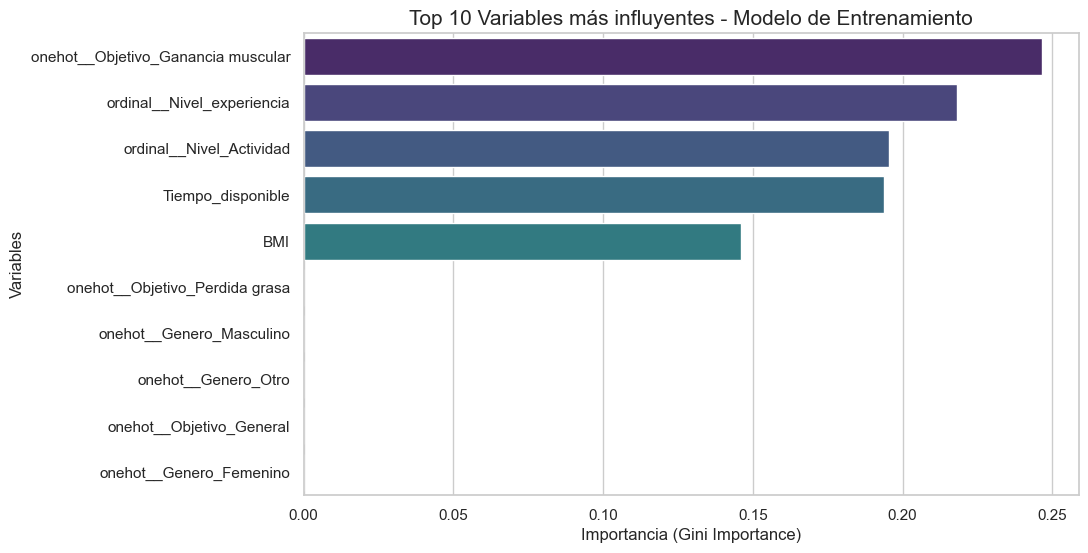

In [35]:
importances = grid_tree_entrenamiento.best_estimator_['classifier'].feature_importances_
cat_names = list(grid_tree_entrenamiento.best_estimator_['preprocessor']
                 .transformers_[0][1].get_feature_names_out())
num_cols_final = [c for c in (numerical_cols + binary_cols) if c not in ['Alcohol', 'Fumador', 'Peso']]
all_feature_names = cat_names + num_cols_final

importancia_entrenamiento = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
print(importancia_entrenamiento.head(10))

# Configuración de estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(x=importancia_entrenamiento.head(10).values, 
            y=importancia_entrenamiento.head(10).index, 
            hue=importancia_entrenamiento.head(10).index,
            palette="viridis",
            legend=False)

plt.title('Top 10 Variables más influyentes - Modelo de Entrenamiento', fontsize=15)
plt.xlabel('Importancia (Gini Importance)', fontsize=12)
plt.ylabel('Variables', fontsize=12)

plt.show()

El análisis de las variables de mayor peso revela que el modelo de entrenamiento ignora por completo variables demográficas como el género (importancia 0.0) y se centra exclusivamente en el perfil de rendimiento:

1. **Objetivo (Ganancia Muscular):** Es el predictor principal (24.6%).
2. **Niveles de Experiencia y Actividad:** Suman casi el 41% de la decisión, lo que es coherente con una asignación técnica de cargas.
3. **BMI y Tiempo:** Actúan como variables de ajuste final.

**Conclusión del F1=1.0:** El desempeño perfecto se debe a que el dataset de entrenamiento sigue una lógica de reglas de decisión puras sin variabilidad aleatoria. Esto sugiere que el modelo ha capturado perfectamente el protocolo actual del gimnasio, aunque podría ser vulnerable a casos que no sigan estas reglas estrictas.

Se ejecuta ahora el modelo para el plan de nutrición:

In [24]:
# Ejecución para Nutrición
grid_tree_nutricion = run_tree_gridsearch(
    "Plan de Nutrición (Árbol)", y_nutricion_train, y_nutricion_test
)

Fitting 5 folds for each of 64 candidates, totalling 320 fits

RESULTADOS PARA: Plan de Nutrición (Árbol)
Best Params: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 20}
F1-Macro (Test): 0.9976

Reporte de Clasificación:
                precision    recall  f1-score   support

   Balanceado       1.00      1.00      1.00       819
       Basico       1.00      0.99      0.99       465
Especializado       1.00      1.00      1.00       125
     Sin plan       1.00      1.00      1.00       531

     accuracy                           1.00      1940
    macro avg       1.00      1.00      1.00      1940
 weighted avg       1.00      1.00      1.00      1940



Ingesta_proteinas                 2.121112e-01
onehot__Objetivo_Resistencia      2.038836e-01
BMI                               1.760402e-01
Alcohol_semana                    1.574140e-01
Score_micronutrientes             1.468006e-01
onehot__Objetivo_General          1.036633e-01
Tiempo_disponible                 8.706422e-05
onehot__Condicion_salud_Lesion    1.427536e-15
onehot__Condicion_salud_Asma      3.063539e-16
ordinal__Nivel_experiencia        2.105852e-16
dtype: float64


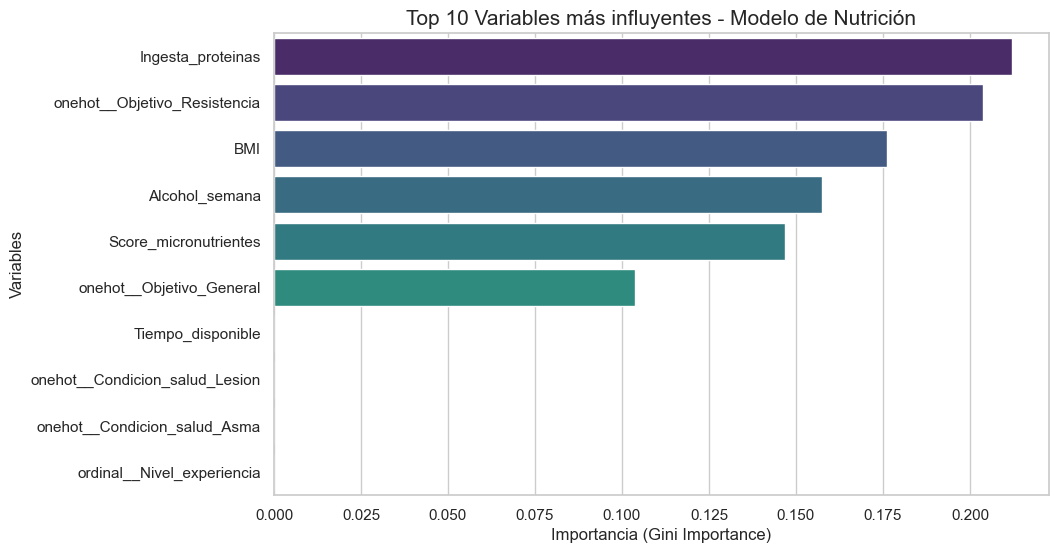

In [36]:
importances_nut = grid_tree_nutricion.best_estimator_['classifier'].feature_importances_
cat_names = list(grid_tree_nutricion.best_estimator_['preprocessor']
                 .transformers_[0][1].get_feature_names_out())
num_cols_final = [c for c in (numerical_cols + binary_cols) if c not in ['Alcohol', 'Fumador', 'Peso']]
all_feature_names_nut = cat_names + num_cols_final

importancia_nutricion = pd.Series(importances_nut, index=all_feature_names_nut).sort_values(ascending=False)
print(importancia_nutricion.head(10))

# Configuración de estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(x=importancia_nutricion.head(10).values, 
            y=importancia_nutricion.head(10).index, 
            hue=importancia_nutricion.head(10).index,
            palette="viridis",
            legend=False)

plt.title('Top 10 Variables más influyentes - Modelo de Nutrición', fontsize=15)
plt.xlabel('Importancia (Gini Importance)', fontsize=12)
plt.ylabel('Variables', fontsize=12)

plt.show()

El análisis de las variables de mayor peso para el modelo de nutrición muestra una distribución más equilibrada entre factores metabólicos y de hábitos, ignorando variables demográficas y condiciones de salud (importancia cercana a 0.0):

1. **Ingesta de Proteínas y Objetivo:** Son los predictores principales (suman 41.6%). El modelo prioriza el estado nutricional actual y la meta deportiva para definir la dieta.
2. **BMI y Alcohol a la semana:** Representan casi el 33.3% de la decisión. Esto indica que el sistema ajusta la recomendación basándose en la composición corporal y el impacto calórico de los hábitos de consumo.
3. **Score de Micronutrientes:** Actúa como la variable de ajuste final (14.6%) para asegurar el equilibrio vitamínico del plan.

**Conclusión del F1=0.998:** El desempeño casi perfecto confirma que la recomendación nutricional sigue un algoritmo de asignación determinístico basado en métricas de rendimiento y biometría.

## Comparativa de Modelos
La siguiente tabla resume el rendimiento de los mejores modelos encontrados mediante búsqueda de hiperparámetros.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    return [round(p, 4), round(r, 4), round(f1, 4)]

# Crear la estructura de la tabla
data = {
    'Objetivo': ['Entrenamiento', 'Entrenamiento', 'Nutrición', 'Nutrición'],
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Regresión Logística', 'Árbol de Decisión'],
    'Precisión (Macro)': [
        get_metrics(grid_entrenamiento, X_test, y_entrenamiento_test)[0],
        get_metrics(grid_tree_entrenamiento, X_test, y_entrenamiento_test)[0],
        get_metrics(grid_nutricion, X_test, y_nutricion_test)[0],
        get_metrics(grid_tree_nutricion, X_test, y_nutricion_test)[0]
    ],
    'Recall (Macro)': [
        get_metrics(grid_entrenamiento, X_test, y_entrenamiento_test)[1],
        get_metrics(grid_tree_entrenamiento, X_test, y_entrenamiento_test)[1],
        get_metrics(grid_nutricion, X_test, y_nutricion_test)[1],
        get_metrics(grid_tree_nutricion, X_test, y_nutricion_test)[1]
    ],
    'F1-Score (Macro)': [
        get_metrics(grid_entrenamiento, X_test, y_entrenamiento_test)[2],
        get_metrics(grid_tree_entrenamiento, X_test, y_entrenamiento_test)[2],
        get_metrics(grid_nutricion, X_test, y_nutricion_test)[2],
        get_metrics(grid_tree_nutricion, X_test, y_nutricion_test)[2]
    ]
}

df_comparativo = pd.DataFrame(data)

df_comparativo

,Objetivo,Modelo,Precisión (Macro),Recall (Macro),F1-Score (Macro)
0,Entrenamiento,Regresión Logística,0.6824,0.6542,0.6566
1,Entrenamiento,Árbol de Decisión,1.0000,1.0000,1.0000
2,Nutrición,Regresión Logística,0.7397,0.6952,0.7118
3,Nutrición,Árbol de Decisión,0.9979,0.9974,0.9976


* En ambos objetivos (Entrenamiento y Nutrición), el **Árbol de Decisión** superó significativamente a la **Regresión Logística**. Esto confirma que las reglas de negocio del gimnasio no son lineales y dependen de condiciones específicas de los clientes.
* **Estabilidad del Recall:** Mientras que la Regresión Logística presentaba un recall bajo en ciertas clases (como el Plan Bajo), el Árbol de Decisión logra capturar casi la totalidad de los casos en todas las categorías.
* **Análisis de Precisión:** La precisión perfecta del árbol en Entrenamiento (1.0) frente al 0.68 de la logística sugiere que el modelo basado en reglas es el más apto para replicar el protocolo de SmartAlpes, siempre que se vigile el riesgo de sobreajuste.